# 2. Speech Audio Denoising Using a Pretrained Model 

Use a pretrained speech denoising model to remove background noise from speech recordings. The model should be used for inference only; training or fine-tuning a new denoising model is not required. 

## Tasks 

- Load noisy speech samples from the selected dataset. 

- Use a pretrained denoising model such as DTLN. 

- Run inference to generate denoised speech. 

- Compare the noisy and denoised audio using waveforms and spectrograms. 

- Save the denoised audio files. 

## Visual Output 

- Noisy and denoised spectrograms. 

- Waveform comparison before and after denoising. 

## Deliverables 

- A properly executed Jupyter Notebook (.ipynb). 

- Denoised audio samples. 

In [1]:
import os
import subprocess
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display

In [2]:
os.makedirs("output", exist_ok=True)

In [6]:
subprocess.run([
    "python",
    "DTLN/run_evaluation.py",
    "-i", "dataset",
    "-o", "output",
    "-m", "DTLN/pretrained_model/model.h5"
], check=True)

CompletedProcess(args=['python', 'DTLN/run_evaluation.py', '-i', 'dataset', '-o', 'output', '-m', 'DTLN/pretrained_model/model.h5'], returncode=0)

In [13]:
noisy, sr = librosa.load("dataset/sample.wav", sr=None)
denoised, d_sr = librosa.load("output/sample.wav", sr=None)
print(f"Sample Rate \nNoisy: {sr}\nDenoised: {d_sr}")

Sample Rate 
Noisy: 48000
Denoised: 16000


In [14]:
print("Original Noisy Audio")
display(Audio(noisy, rate=sr))

print("DTLN Denoised Audio")
display(Audio(denoised, rate=d_sr))

Original Noisy Audio


DTLN Denoised Audio


In [15]:
def plot_spec(audio, sr, title):

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    plt.figure(figsize=(10,4))

    librosa.display.specshow(
        mel_db,
        sr=sr,
        x_axis="time",
        y_axis="mel"
    )

    plt.colorbar(format="%+2.0f dB")
    plt.title(title)
    plt.tight_layout()
    plt.show()

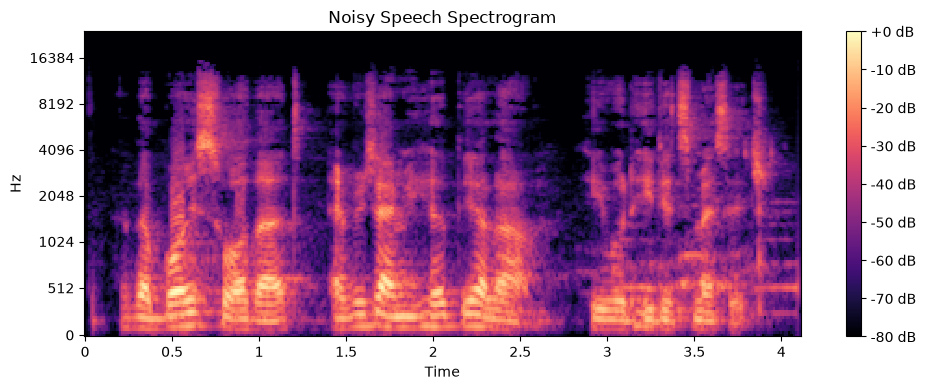

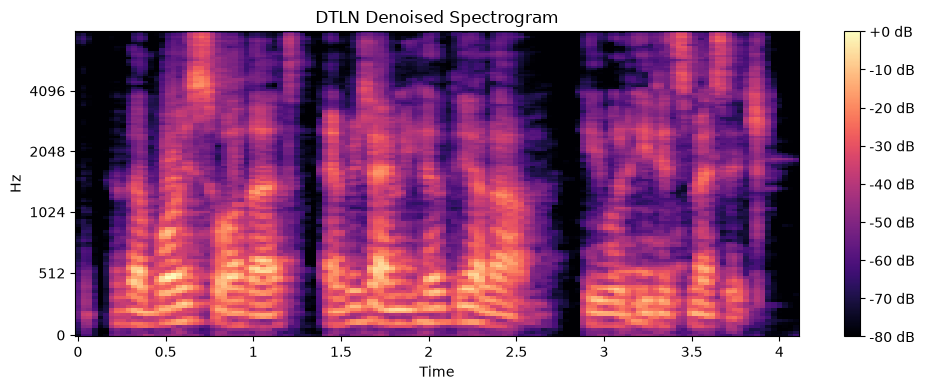

In [16]:
plot_spec(noisy, sr, "Noisy Speech Spectrogram")
plot_spec(denoised, d_sr, "DTLN Denoised Spectrogram")